# EDA: VIX-basiertes Ampel-System fuer die Morgenroutine

Ziel dieses Notebooks ist die explorative Analyse historischer VIX- und S&P-500-Daten, um eine sinnvolle Ampel-Logik (Gruen / Gelb / Rot) fuer den Marktzustand abzuleiten.

**Zu pruefende Hypothesen:**

1. Der VIX bewegt sich meist in einem ruhigen Band ("Normalzustand") und zeigt nur in Stressphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) deutliche Ausschlaege nach oben.
2. Hohe VIX-Werte korrelieren mit negativen/volatilen S&P-500-Renditen (inverse Beziehung VIX vs. Aktienmarkt).
3. Der VIX zeigt Volatility Clustering (Autokorrelation), d.h. hohe/niedrige Werte treten in Clustern auf - relevant fuer die Stabilitaet einer taeglichen Ampel.
4. Anhand der historischen Verteilung (Quantile) lassen sich plausible Schwellenwerte fuer Gruen/Gelb/Rot ableiten (z.B. grob orientiert an gaengigen Marktfaustregeln: <20 ruhig, 20-30 angespannt, >30 Ausnahmezustand) - wir pruefen, ob diese Faustregeln zu den Daten passen.
5. Der Uebergang zwischen den Zustaenden (z.B. Gruen -> Rot) - wie abrupt geschieht das, und wie lange dauern Rot-Phasen typischerweise?
"

## 1. Setup & Daten laden

Die Rohdaten wurden bereits per `src/fetch_data.py` von Yahoo Finance geladen und liegen als CSV in `data/` (VIX und S&P 500, taeglich, ab 2007-01-01).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = "../data"

# Ampel-Farben fuer konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

In [2]:
vix = pd.read_csv(f"{DATA_DIR}/vix_raw.csv", index_col="Date", parse_dates=True)
sp500 = pd.read_csv(f"{DATA_DIR}/sp500_raw.csv", index_col="Date", parse_dates=True)

print("VIX:", vix.shape, vix.index.min().date(), "-", vix.index.max().date())
print("S&P 500:", sp500.shape, sp500.index.min().date(), "-", sp500.index.max().date())

vix.head()

VIX: (4929, 6) 2007-01-03 - 2026-08-05
S&P 500: (4927, 6) 2007-01-03 - 2026-08-04


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2007-01-03,12.04,12.04,12.75,11.53,12.16,0
2007-01-04,11.51,11.51,12.42,11.28,12.40,0
2007-01-05,12.14,12.14,12.25,11.68,11.84,0
2007-01-08,12.00,12.00,12.83,11.78,12.48,0
2007-01-09,11.91,11.91,12.47,11.69,11.86,0


## 2. Datenqualitaet

Pruefung auf fehlende Werte, Duplikate und abweichende Handelstage zwischen VIX und S&P 500 (z.B. durch unterschiedliche Feiertagskalender oder Datenluecken bei Yahoo Finance).

In [3]:
print("Fehlende Werte VIX:\
", vix.isna().sum())
print("\
Fehlende Werte S&P 500:\
", sp500.isna().sum())
print("\
Duplizierte Indexwerte VIX:", vix.index.duplicated().sum())
print("Duplizierte Indexwerte S&P 500:", sp500.index.duplicated().sum())

only_in_vix = vix.index.difference(sp500.index)
only_in_sp500 = sp500.index.difference(vix.index)
print(f"\
Handelstage nur im VIX: {len(only_in_vix)}")
print(f"Handelstage nur im S&P 500: {len(only_in_sp500)}")

Fehlende Werte VIX: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte S&P 500: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte VIX: 0
Duplizierte Indexwerte S&P 500: 0
Handelstage nur im VIX: 2
Handelstage nur im S&P 500: 0


In [4]:
df = pd.DataFrame({
    "vix_close": vix["Close"],
    "sp500_close": sp500["Close"],
}).dropna()

df["sp500_return"] = df["sp500_close"].pct_change() * 100  # in %
df["vix_change"] = df["vix_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4927


,vix_close,sp500_close,sp500_return,vix_change
count,4927.000000,4927.000000,4926.000000,4926.000000
mean,19.788230,2804.092701,0.042198,0.000905
std,8.700132,1669.949594,1.241855,1.986202
min,9.140000,676.530029,-11.984055,-18.710003
25%,14.090000,1418.445007,-0.413199,-0.770000
50%,17.500000,2173.600098,0.072402,-0.110000
75%,22.695001,3958.670044,0.596015,0.600000
max,82.690002,7736.520020,11.580037,24.860001


## 3. Hypothese 1: Ruhiges Fahrwasser vs. Stressphasen

Zeitreihe des VIX ueber den gesamten Zeitraum mit bekannten Krisenphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) zur visuellen Einordnung.

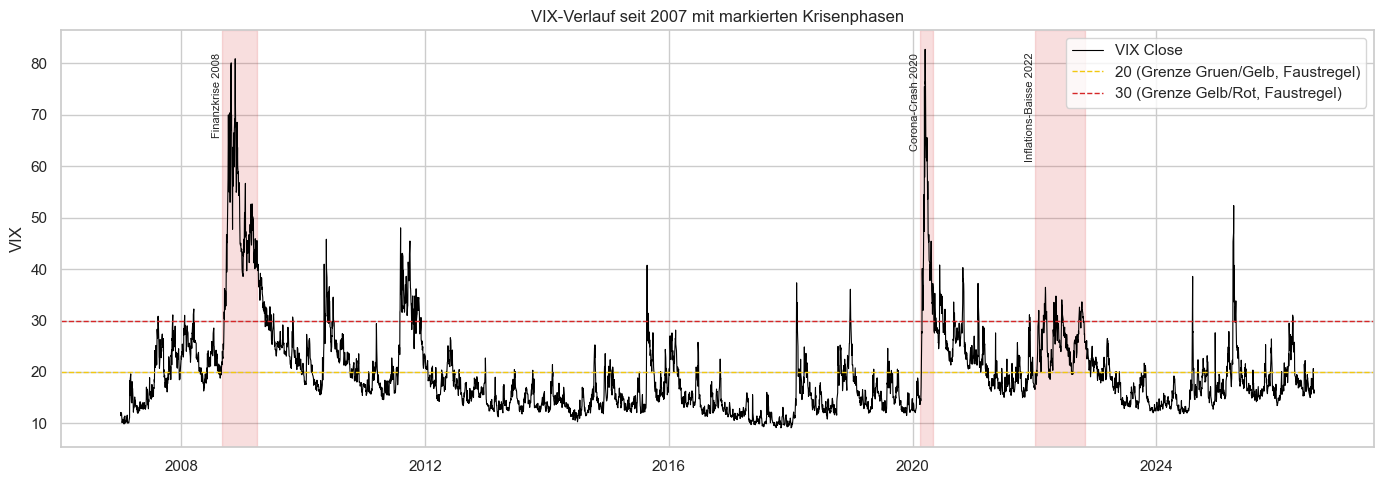

In [5]:
crisis_periods = {
    "Finanzkrise 2008": ("2008-09-01", "2009-03-31"),
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.8, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(20, color=COLOR_YELLOW, linestyle="--", linewidth=1, label="20 (Grenze Gruen/Gelb, Faustregel)")
ax.axhline(30, color=COLOR_RED, linestyle="--", linewidth=1, label="30 (Grenze Gelb/Rot, Faustregel)")
ax.set_title("VIX-Verlauf seit 2007 mit markierten Krisenphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Hypothese 4: Verteilung des VIX & plausible Ampel-Schwellenwerte

Histogramm und Quantile der VIX-Werte, um zu pruefen, wie gut gaengige Faustregel-Schwellen (20 / 30) zur tatsaechlichen Verteilung passen und welcher Anteil der Handelstage in welche Ampelphase faellt.

VIX-Quantile:
0.50    17.50
0.70    21.39
0.75    22.70
0.80    24.29
0.90    29.11
0.95    35.29
0.99    56.51
Name: vix_close, dtype: float64


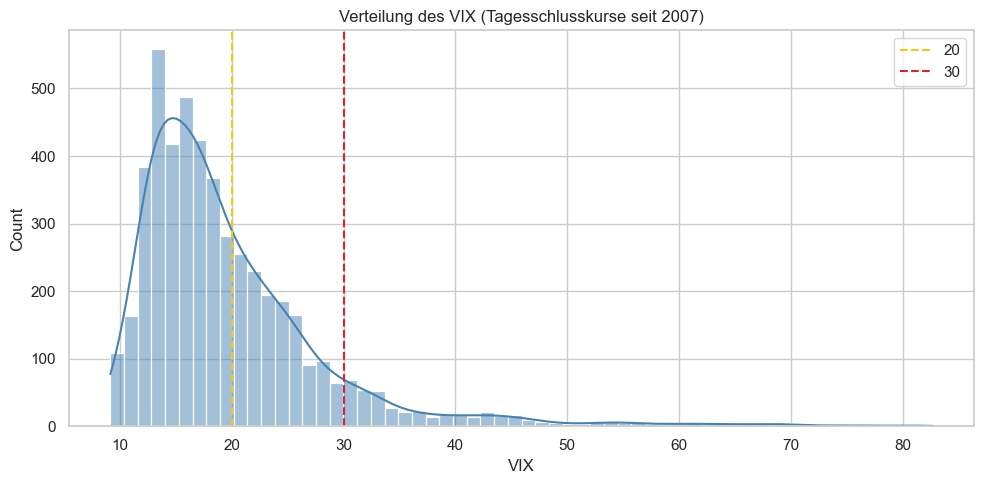

Gruen (<20): 64.1% der Handelstage
Gelb (20-30): 26.8% der Handelstage
Rot (>30): 9.1% der Handelstage


In [6]:
quantiles = df["vix_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("VIX-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["vix_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(20, color=COLOR_YELLOW, linestyle="--", label="20")
ax.axvline(30, color=COLOR_RED, linestyle="--", label="30")
ax.set_title("Verteilung des VIX (Tagesschlusskurse seit 2007)")
ax.set_xlabel("VIX")
ax.legend()
plt.tight_layout()
plt.show()

for low, high, label in [(0, 20, "Gruen (<20)"), (20, 30, "Gelb (20-30)"), (30, np.inf, "Rot (>30)")]:
    share = ((df["vix_close"] >= low) & (df["vix_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")

## 5. Hypothese 2: VIX vs. S&P-500-Renditen

Untersuchung des inversen Zusammenhangs: hohe VIX-Tagesaenderungen bzw. VIX-Niveaus sollten mit negativen/volatilen S&P-500-Tagesrenditen einhergehen.

Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: -0.815
Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: -0.143


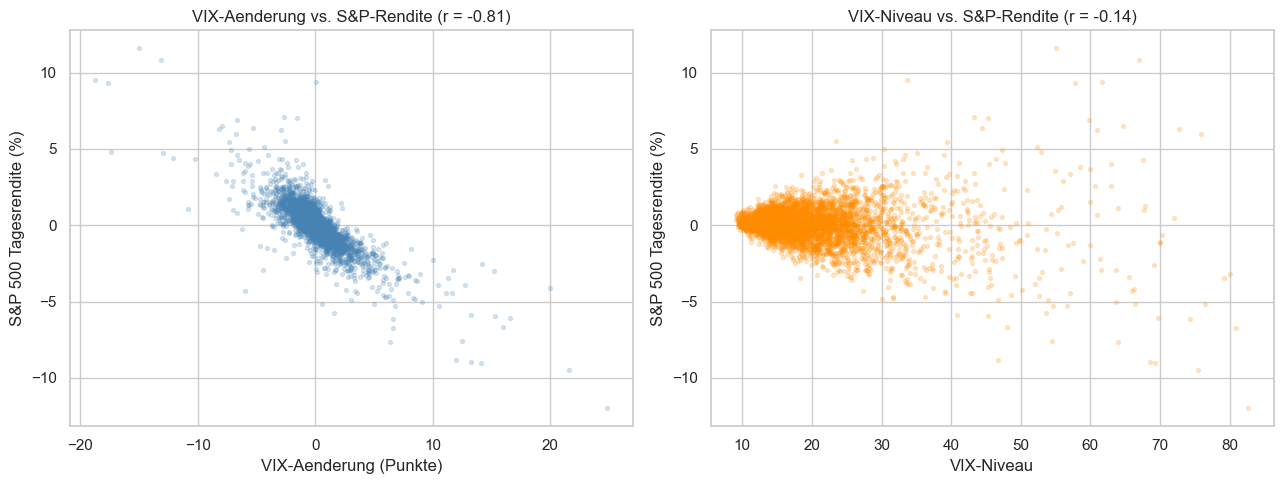

In [7]:
corr_change = df[["vix_change", "sp500_return"]].corr().iloc[0, 1]
corr_level = df[["vix_close", "sp500_return"]].corr().iloc[0, 1]
print(f"Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["vix_change"], df["sp500_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("VIX-Aenderung (Punkte)")
axes[0].set_ylabel("S&P 500 Tagesrendite (%)")
axes[0].set_title(f"VIX-Aenderung vs. S&P-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["vix_close"], df["sp500_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("VIX-Niveau")
axes[1].set_ylabel("S&P 500 Tagesrendite (%)")
axes[1].set_title(f"VIX-Niveau vs. S&P-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

## 6. Hypothese 3: Volatility Clustering (Autokorrelation)

Wenn der VIX stark autokorreliert ist, aendert sich die Ampelfarbe von Tag zu Tag selten sprunghaft - das ist fuer eine taegliche Morgenroutine wichtig (keine staendigen Fehlalarme durch Rauschen).

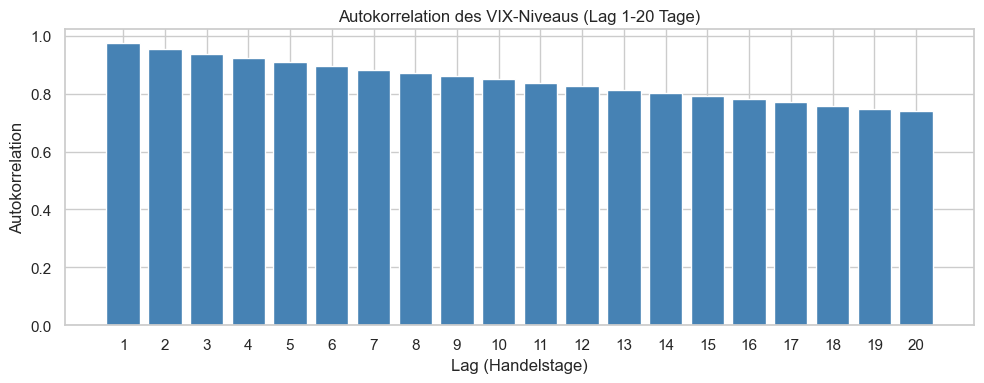

Autokorrelation Lag 1 (Vortag): 0.974
Autokorrelation Lag 5 (Vorwoche): 0.909


In [8]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["vix_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des VIX-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['vix_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['vix_close'].autocorr(5):.3f}")

## 7. Hypothese 5: Dauer der Ampelphasen

Mit den Faustregel-Schwellen (20 / 30) klassifizieren wir jeden Handelstag in Gruen/Gelb/Rot und untersuchen, wie lange zusammenhaengende Phasen jeweils dauern - wichtig, um einzuschaetzen, ob die Ampel stabil genug fuer eine taegliche Routine ist.

In [9]:
def ampel(vix_value: float) -> str:
    if vix_value < 20:
        return "gruen"
    elif vix_value < 30:
        return "gelb"
    return "rot"

df["ampel"] = df["vix_close"].apply(ampel)

# zusammenhaengende Phasen identifizieren
phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\
Die 5 laengsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())

Anzahl Phasenwechsel gesamt: 404
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   201.0   6.567164  2.0   80.0
gruen  150.0  21.053333  4.0  312.0
rot     53.0   8.471698  2.0  170.0
Die 5 laengsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
33         rot 2008-09-15 2009-05-18         170
101        rot 2011-08-04 2011-10-13          50
230        rot 2020-02-27 2020-05-07          50
109        rot 2011-11-09 2011-11-29          14
236        rot 2020-06-11 2020-06-30          14


## 9. Vertiefende Hypothesen fuer die Ampel-Logik

Die folgenden vier Abschnitte pruefen spezifische, fuer die Ampel-Logik relevante Hypothesen. Jeder Abschnitt enthaelt Code, eine Visualisierung und eine kurze Ergebnis-Interpretation.

Als gemeinsame Referenzgroesse wird der VIX-Schwellenwert 30 verwendet (gaengige Marktfaustregel fuer den "Ausnahmezustand"/Rot-Bereich, siehe auch Abschnitt 4 oben). Abschnitt 11 ("VIX-Schwellenwerte") ueberprueft explizit, ob sich dieser Wert anhand der Daten bestaetigen laesst.

In [10]:
# Gemeinsame Konfiguration fuer die folgenden Abschnitte
VIX_THRESHOLD_ROT = 30  # Faustregel-Schwelle "Ausnahmezustand", wird in Abschnitt 11 validiert


def forward_hit_rate(signal_mask, horizon, threshold=VIX_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der VIX-Schlusskurs
    innerhalb der naechsten `horizon` Handelstage mindestens einmal ueber
    `threshold` steigt. Tage ohne vollstaendiges Folgefenster (zu nah am
    Datenende) werden ausgeschlossen."""
    vix_values = df["vix_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = vix_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue  # kein vollstaendiges Folgefenster mehr vorhanden
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)

### 9.1 Hypothese: Neues 3-Monats-Hoch als Fruehwarnsignal

**Fragestellung:** Wenn der VIX ein neues 3-Monats-Hoch erreicht (hoechster Schlusskurs der letzten ca. 63 Handelstage, also 3 Kalendermonate zu je ~21 Handelstagen), wie oft folgt in den naechsten 5 bzw. 10 Handelstagen tatsaechlich eine Phase mit VIX > 30? Wir berechnen die Trefferquote und vergleichen sie mit der unbedingten Basis-Wahrscheinlichkeit, um den Mehrwert des Signals einzuordnen.

In [11]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["vix_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt ueber dem rollierenden 3-Monats-Hoch
new_3m_high = df["vix_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 153
Trefferquote nach Signal, 5 Tage:  39.2%  (Baseline: 12.3%)
Trefferquote nach Signal, 10 Tage: 41.8%  (Baseline: 15.2%)


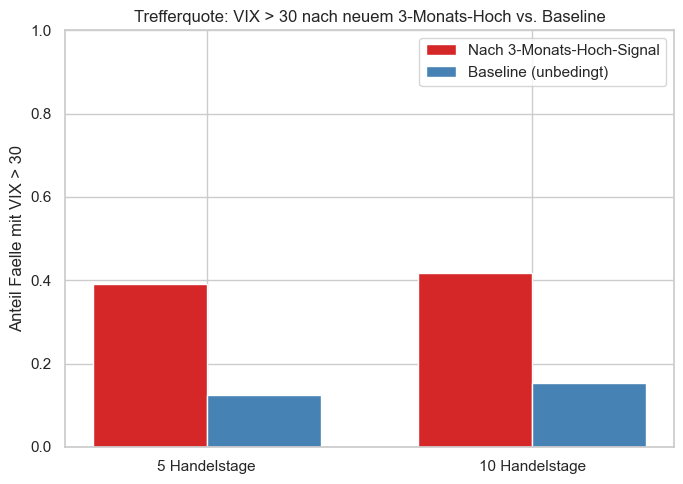

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Faelle mit VIX > {VIX_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: VIX > 30 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Ueber den Beobachtungszeitraum gab es 153 neue 3-Monats-Hochs. Nach einem solchen Signal lag der VIX in 39,2% der Faelle innerhalb von 5 Handelstagen und in 41,8% der Faelle innerhalb von 10 Handelstagen mindestens einmal ueber 30 -- gegenueber einer unbedingten Basiswahrscheinlichkeit von nur 12,3% bzw. 15,2%. Das Signal erhoeht die Trefferquote also etwa um den Faktor 3, bleibt aber mit ~40% ein Minderheits-Ereignis und damit kein zuverlaessiger Alleinauftrag fuer die Ampel. Hinweis: Da VIX-Anstiege oft mehrere Tage in Folge neue Hochs erzeugen, sind die Signaltage nicht vollstaendig unabhaengig voneinander, was die Trefferquote tendenziell etwas nach oben verzerren kann.

### 9.2 Hypothese: "3-Punkte-Umkehr" als Beruhigungssignal

**Fragestellung:** Definiere Tage, an denen gilt: Open >= 20 UND Intraday-High > Open UND (Intraday-High - Close) >= 3 -- der VIX schiesst also im Tagesverlauf deutlich nach oben, gibt den Anstieg bis zum Handelsschluss aber wieder groesstenteils ab. Faellt der VIX an den 5 Folgetagen im Schnitt (= Beruhigung) oder steigt er haeufig weiter?

In [13]:
# Signal-Definition: ausgepraegte Intraday-Umkehr im VIX
#   - Open >= 20            -> Markt startet bereits angespannt
#   - High > Open            -> im Tagesverlauf zieht der VIX weiter an
#   - (High - Close) >= 3    -> der Tag schliesst aber mindestens 3 Punkte unter dem Hoch
vix_ohlc = vix[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (vix_ohlc["Open"] >= 20)
    & (vix_ohlc["High"] > vix_ohlc["Open"])
    & ((vix_ohlc["High"] - vix_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

# VIX-Entwicklung an den 5 Folgetagen, relativ zum Schlusskurs des Signaltags
HORIZON_H2 = 5
vix_close_values = df["vix_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue  # nicht genug Folgetage vorhanden
    base = vix_close_values.iloc[pos]
    path = vix_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche VIX-Aenderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median VIX-Aenderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Faelle mit niedrigerem VIX nach {HORIZON_H2} Tagen: {share_falling:.1%}")

Anzahl '3-Punkte-Umkehr'-Signale: 272
Auswertbare Signale: 272
Durchschnittliche VIX-Aenderung nach 5 Tagen: -1.51 Punkte
Median VIX-Aenderung nach 5 Tagen:            -2.02 Punkte
Anteil Faelle mit niedrigerem VIX nach 5 Tagen: 67.3%


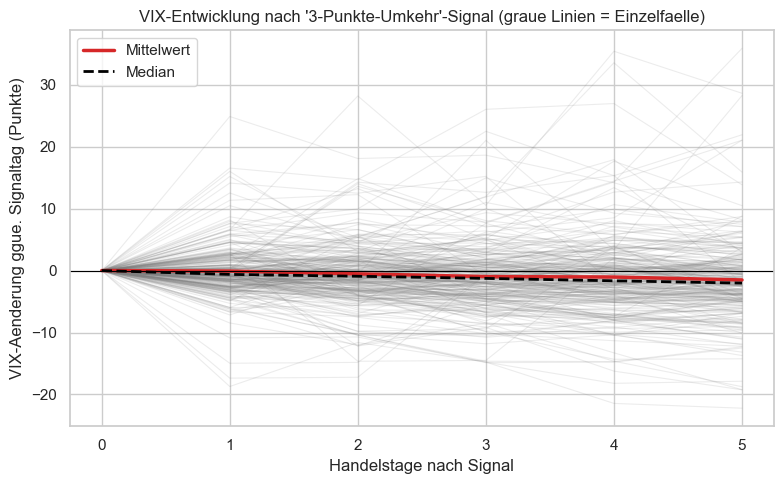

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("VIX-Aenderung ggue. Signaltag (Punkte)")
ax.set_title("VIX-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfaelle)")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Von 272 identifizierten '3-Punkte-Umkehr'-Signalen fiel der VIX in 67,3% der Faelle innerhalb von 5 Handelstagen unter den Stand des Signaltags, im Schnitt um 1,51 Punkte (Median: -2,02 Punkte). Die Hypothese der Beruhigung wird damit tendenziell bestaetigt: in etwa zwei von drei Faellen deutet das Muster tatsaechlich auf ein nachlassendes Stresslevel hin, in knapp einem Drittel der Faelle setzt sich der Anstieg jedoch fort -- das Signal ist also ein nuetzlicher, aber kein eindeutiger Indikator.

### 9.3 Hypothese: VIX-Schwellenwerte anhand Verteilung und Stressphasen

**Fragestellung:** Wie ist der VIX ueber den gesamten Zeitraum verteilt (Perzentile 50/75/90/95)? Und ab welchem Niveau heben sich bekannte Stressphasen (Finanzkrise 2008, Covid-Crash 2020, Inflations-Baisse 2022) im Zeitverlauf sichtbar vom Normalzustand ab? Daraus leiten wir sinnvolle Schwellen fuer Gelb/Rot ab. Die Krisenphasen (`crisis_periods`) wurden bereits in Abschnitt 3 definiert und werden hier wiederverwendet.

In [15]:
percentiles_h3 = df["vix_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("VIX-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nVIX waehrend Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))
print("\nVIX ausserhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))

VIX-Perzentile (gesamter Zeitraum):
0.50    17.50
0.75    22.70
0.90    29.11
0.95    35.29
Name: vix_close, dtype: float64

VIX waehrend Stressphasen (Median / Min / Max):
median    31.77
min       14.38
max       82.69
Name: vix_close, dtype: float64

VIX ausserhalb von Stressphasen (Median / Min / Max):
median    16.90
min        9.14
max       52.33
Name: vix_close, dtype: float64


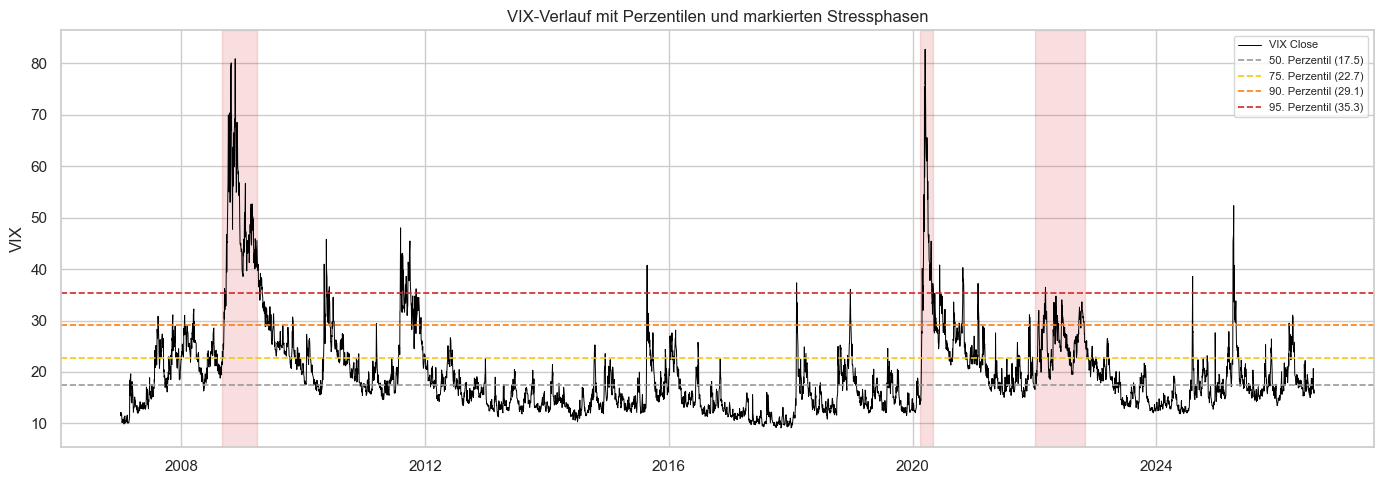

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.7, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("VIX-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Die Perzentile (50/75/90/95 = 17,5/22,7/29,1/35,3) zeigen, dass der Median-VIX waehrend der markierten Stressphasen (31,77) nahe am 90. Perzentil der Gesamtverteilung liegt und deutlich ueber dem 75. Perzentil -- die bisherige Faustregel-Schwelle von 30 fuer 'Rot' ist damit gut durch die Daten gedeckt, waehrend sich 'Gelb' eher im Bereich des 75.-90. Perzentils (ca. 20-29) verorten laesst. Allerdings zeigt der Minimalwert von 14,38 innerhalb der Stressphasen und der Maximalwert von 52,33 ausserhalb, dass die grob definierten Kalenderfenster nicht trennscharf sind: einzelne ruhige Tage fallen in Krisenzeitraeume und umgekehrt loesen auch ausserhalb der markierten Phasen kurzzeitig hohe VIX-Spitzen aus (z.B. Einzeltagesereignisse).

### 9.4 Hypothese: Divergenz zum Index als Fruehindikator

**Fragestellung:** Normalerweise sind VIX und S&P 500 invers korreliert (vgl. Abschnitt 5). Wie oft steigen beide an einem Handelstag gleichzeitig ("untypischer Gleichlauf")? Wir berechnen dazu den Anteil solcher Tage in einem rollierenden 5- bzw. 10-Tage-Fenster und pruefen, ob ein hoher Anteil (>60%) historisch mit nachfolgenden Marktturbulenzen einhergeht. Als Turbulenz-Definition verwenden wir konsistent zu Abschnitt 9.1: VIX > 30 innerhalb der naechsten 10 Handelstage.

In [17]:
# Tage, an denen S&P 500 UND VIX am selben Tag gleichzeitig gestiegen sind
co_up = (df["sp500_return"] > 0) & (df["vix_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: VIX > 30 in den naechsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 5 von 4923 (0.1%)
P(VIX > 30 in den naechsten 10 Tagen | Divergenz > 60%): 0.0%
P(VIX > 30 in den naechsten 10 Tagen), Baseline: 15.2%


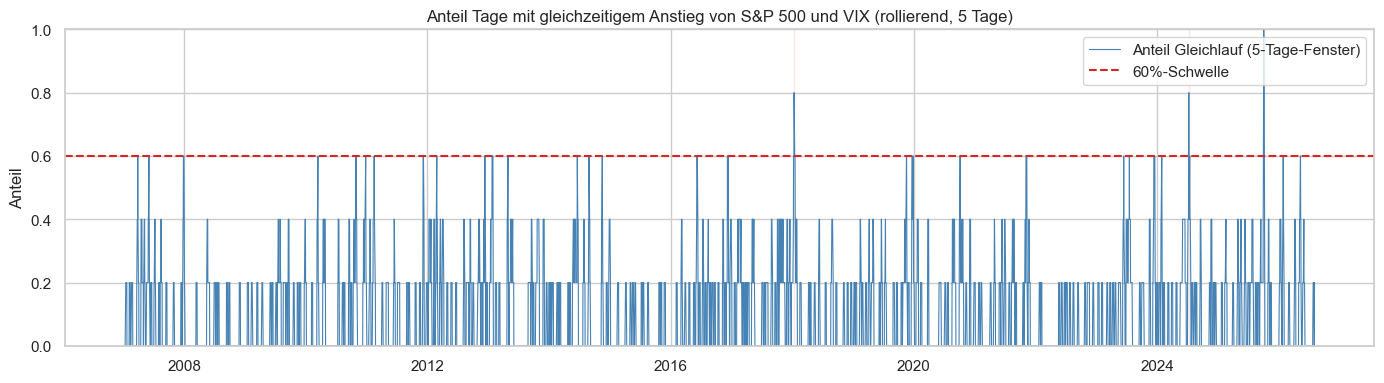

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von S&P 500 und VIX (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von S&P 500 und VIX an mindestens 60% der Tage eines 5-Tage-Fensters ist mit 5 von 4.923 Fenstern (0,1%) ein extrem seltenes Ereignis. In diesen wenigen Faellen folgte in keinem einzigen (0,0%) innerhalb von 10 Handelstagen eine Phase mit VIX > 30, gegenueber einer Basiswahrscheinlichkeit von 15,2% -- die Hypothese wird in dieser Form durch die Daten nicht gestuetzt. Wichtiger Vorbehalt: Mit nur 5 Beobachtungen ist die Stichprobe viel zu klein fuer eine belastbare Aussage; fuer die Ampel-Logik waere entweder eine weniger strenge Divergenz-Definition (z.B. niedrigerer Schwellenwert oder laengeres Fenster) oder ein laengerer Beobachtungszeitraum noetig, um genug Faelle fuer eine verlaessliche Einschaetzung zu erhalten.

## 13. Fazit (auszufuellen nach Ausfuehrung)

- Hypothese 1: ...
- Hypothese 2: ...
- Hypothese 3: ...
- Hypothese 4: ...
- Hypothese 5: ...
- Hypothese 9.1 (3-Monats-Hoch): ...
- Hypothese 9.2 (3-Punkte-Umkehr): ...
- Hypothese 9.3 (Schwellenwerte): ...
- Hypothese 9.4 (Divergenz zum Index): ...

**Naechste Schritte:** Basierend auf den obigen Befunden konkrete Schwellenwerte fuer die Ampel-Logik festlegen und in `src/` als wiederverwendbare Funktion implementieren."